<a href="https://colab.research.google.com/github/Nolan-McKenna/low_entropy_watermarking/blob/master/watermark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Low-Entropy LLM Watermarking

**Baseline**: Soft red-list watermark from Kirchenbauer et al. (ICML 2023)  
Paper: https://arxiv.org/abs/2301.10226  
Original code: https://github.com/jwkirchenbauer/lm-watermarking

This notebook is for demonstration purposes. The core logic lives in:
- `watermark.py` — `WatermarkLogitsProcessor` + `WatermarkDetector`
- `generate.py` — bulk generation on C4 RealNewsLike
- `evaluate.py` — z-scores, PPL, ROC/AUC

In [2]:
!git clone https://github.com/Nolan-McKenna/low_entropy_watermarking.git
%cd low_entropy_watermarking

Cloning into 'low_entropy_watermarking'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 20), reused 33 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 23.31 KiB | 11.65 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/low_entropy_watermarking


In [36]:
!git pull

remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 1), reused 3 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 3.25 KiB | 3.25 MiB/s, done.
From https://github.com/Nolan-McKenna/low_entropy_watermarking
   142a7ce..91774e9  master     -> origin/master
Updating 142a7ce..91774e9
Fast-forward
 make_low_entropy_prompts.py | 191 ++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 191 insertions(+)
 create mode 100644 make_low_entropy_prompts.py


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from watermark import WatermarkLogitsProcessor, WatermarkDetector

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "facebook/opt-1.3b"
GAMMA = 0.25
DELTA = 2.0
HASH_KEY = 15485863

print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE)
model.eval()
print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

Model loaded.


In [5]:
vocab_size = len(tokenizer)

watermark_processor = WatermarkLogitsProcessor(
    vocab_size=vocab_size,
    gamma=GAMMA,
    delta=DELTA,
    hash_key=HASH_KEY,
)

detector = WatermarkDetector(
    vocab_size=vocab_size,
    gamma=GAMMA,
    hash_key=HASH_KEY,
    z_threshold=4.0,
)

## Demo: single prompt

In [6]:
PROMPT = (
    "The quick brown fox jumps over the lazy dog. "
    "In recent news, scientists have discovered"
)

@torch.inference_mode()
def generate(prompt: str, watermarked: bool, max_new_tokens: int = 200) -> str:
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    processors = [watermark_processor] if watermarked else []
    out = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        logits_processor=processors,
    )
    new_tokens = out[0, input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True), new_tokens.tolist()

nw_text, nw_tokens = generate(PROMPT, watermarked=False)
w_text,  w_tokens  = generate(PROMPT, watermarked=True)

print("=== No watermark ===")
print(nw_text[:300])
print()
print("=== Watermarked ===")
print(w_text[:300])

=== No watermark ===
 the Foxes tongue is actually made up of 5 different structures, some made of jelly, other of liquid, and others of gel, making the tongue flexible to the different textures being presented.
But really, who would want to lick that tongue?!

=== Watermarked ===
 that rats are actually much thinner on the inside than they show on the outside (a.k.a they don’t have fat asses). “It was quite a surprise, and our work went well,” said lead investigator Alexander Lopesh. “I should emphasize that rats aren’t slim and tall. They’re very fat, which is not a good th


In [7]:
nw_result = detector.detect(nw_tokens)
w_result  = detector.detect(w_tokens)

print("No-watermark detection:", nw_result)
print("Watermarked detection: ", w_result)

No-watermark detection: {'num_tokens': 50, 'green_token_count': 10, 'z_score': -0.816496580927726, 'is_watermarked': False}
Watermarked detection:  {'num_tokens': 129, 'green_token_count': 69, 'z_score': 7.472429946297629, 'is_watermarked': True}


## Bulk generation on C4

In [27]:
# debug (patch)
!python generate_forced_adp.py --input_file data/generations.jsonl

Loading facebook/opt-1.3b …
Loading weights: 100% 389/389 [00:00<00:00, 1078.51it/s, Materializing param=model.decoder.layers.23.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Config: alpha=0.5  delta_min=1.0  max_tokens=400
[1/500]  len=344  z=9.13  avg_len=344.0
[10/500]  len=126  z=4.08  avg_len=329.7
[20/500]  len=400  z=8.47  avg_len=356.6
[30/500]  len=372  z=8.90  avg_len=362.3
[40/500]  len=400  z=7.43  avg_len=348.8
[50/500]  len=400  z=8.35  avg_len=341.4
[60/500]  len=141  z=4.49  avg_len=343.2
[70/500]  len=400  z=8.01  avg_len=344.5
[80/500]  len=400  z=8.47  avg_len=345.8
[90/500]  len=400  z=8.70  avg_len=347.3
[100/500]  len=400  z=9.51  avg_len=341.4
[110/500]  len=400  z=6.27  avg_len=345.0
[120/500]  len=400  z=7.66 

In [38]:
import os
if os.path.exists('data/generations.jsonl'):
    import json
    print(f'data/generations.jsonl already exists')
else:
    !python generate.py --num_samples 100 --output_file data/generations.jsonl

data/generations.jsonl already exists


In [28]:
!python evaluate.py --compute_ppl --input_file data/generations.jsonl

Loading oracle model facebook/opt-2.7b …
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 517/517 [00:00<00:00, 934.99it/s, Materializing param=model.decoder.layers.31.self_attn_layer_norm.weight]
The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
  scored 50/500
  scored 100/500
  scored 150/500
  scored 200/500
  scored 250/500
  scored 300/500
  scored 350/500
  scored 400/500
  scored 450/500
  scored 500/500

=== Watermark detection (z > 4.0) ===
  TPR fixed:                           0.976
  TPR adaptive:                        0.196
  TPR forced (fixed δ):                1.000
  TPR forced (adaptive δ):             0.980
  FPR (no-watermark false-positive):   0.000
  FNR fixed:                           0.024

=== Z-score statistics ===
 

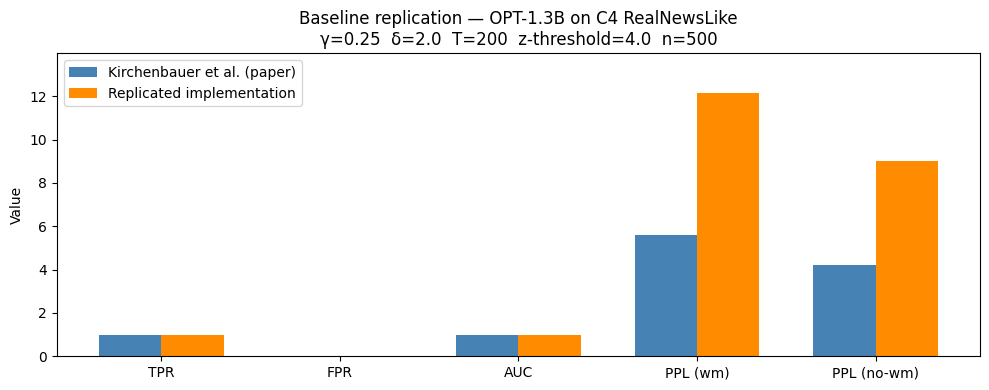


Metric            Paper   Replicated
────────────────────────────────────
TPR               0.970        0.976
FPR               0.010        0.000
AUC               1.000        0.997
PPL (wm)          5.600       12.161
PPL (no-wm)       4.200        8.991


In [29]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

ev = json.loads(Path('data/generations.eval.json').read_text())

# Paper reference values (Kirchenbauer et al. Table 2 + Fig 4c)
# γ=0.25, δ=2.0, T=200, OPT-1.3B
paper = {'TPR': 0.97, 'FPR': 0.01, 'AUC': 1.00, 'PPL (wm)': 5.6, 'PPL (no-wm)': 4.2}
repli = {
    'TPR':        ev['tpr'],
    'FPR':        ev['fpr'],
    'AUC':        ev['auc'],
    'PPL (wm)':   ev.get('w_ppl_mean'),
    'PPL (no-wm)': ev.get('nw_ppl_mean'),
}

metrics     = [k for k in paper if repli[k] is not None]
paper_vals  = [paper[k]  for k in metrics]
repli_vals  = [repli[k]  for k in metrics]

x, w = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, paper_vals, w, label='Kirchenbauer et al. (paper)',  color='steelblue')
ax.bar(x + w/2, repli_vals, w, label='Replicated implementation',    color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Value')
ax.set_title(
    f'Baseline replication — OPT-1.3B on C4 RealNewsLike\n'
    f'γ={ev.get("gamma", 0.25)}  δ={ev.get("delta", 2.0)}  '
    f'T=200  z-threshold=4.0  n=500'
)
ax.legend()
ax.set_ylim(0, max(max(paper_vals), max(repli_vals)) * 1.15)
plt.tight_layout()
plt.savefig('replication_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Metric':<14} {'Paper':>8} {'Replicated':>12}")
print('─' * 36)
for k in metrics:
    print(f"{k:<14} {paper[k]:>8.3f} {repli[k]:>12.3f}")


---
## Extensions: Adaptive δ and Forced Generation

Two extensions beyond the Kirchenbauer et al. baseline:
1. **Adaptive δ** — scales the green-list bias with the Shannon entropy of the current distribution.
2. **Forced generation** — continues generating token-by-token until the running z-score exceeds the detection threshold, guaranteeing detectability at the cost of variable output length.


In [30]:
# Adaptive processor and detector
adaptive_processor = WatermarkLogitsProcessor(
    vocab_size=vocab_size,
    gamma=GAMMA,
    delta=DELTA,
    adaptive=True,
    hash_key=HASH_KEY,
)
detector = WatermarkDetector(
    vocab_size=vocab_size,
    gamma=GAMMA,
    hash_key=HASH_KEY,
    z_threshold=4.0,
)
print('Processors and detector ready.')


Processors and detector ready.


### Per-token entropy: fixed δ vs adaptive δ

The cell below wraps the logits processor to log the normalized entropy and applied δ at each generation step, then plots them side by side. The key claim: in low-entropy positions the adaptive version applies near-zero bias, while the fixed version always applies the full δ regardless of how predictable the next token is.

In [31]:
import math, numpy as np, matplotlib.pyplot as plt

class EntropyLoggingProcessor(WatermarkLogitsProcessor):
    """Thin wrapper that records entropy and applied delta at each step."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.entropy_log = []
        self.delta_log   = []

    def __call__(self, input_ids, scores):
        norm_h = self._normalized_entropy(scores[0])
        applied = self._adaptive_delta(scores[0]) if self.adaptive else self.delta
        self.entropy_log.append(float(norm_h))
        self.delta_log.append(float(applied))
        return super().__call__(input_ids, scores)

N_DEMO = 100
LOW_ENTROPY_PROMPT = (
    "The capital of France is Paris. The capital of Germany is Berlin. "
    "The capital of Italy is Rome. The capital of Spain is"
)

fixed_logger    = EntropyLoggingProcessor(vocab_size=vocab_size, gamma=GAMMA, delta=DELTA, adaptive=False, hash_key=HASH_KEY)
adaptive_logger = EntropyLoggingProcessor(vocab_size=vocab_size, gamma=GAMMA, delta=DELTA, adaptive=True,  hash_key=HASH_KEY)

@torch.inference_mode()
def generate_logged(prompt, proc, n=N_DEMO):
    ids = tokenizer.encode(prompt, return_tensors='pt').to(DEVICE)
    out = model.generate(ids, max_new_tokens=n, do_sample=True, logits_processor=[proc])
    return tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True)

fixed_text    = generate_logged(LOW_ENTROPY_PROMPT, fixed_logger)
adaptive_text = generate_logged(LOW_ENTROPY_PROMPT, adaptive_logger)
print('Fixed:   ', fixed_text[:120])
print('Adaptive:', adaptive_text[:120])


Fixed:     Madrid. The capital of the US is New York City. The capital of the Canadian province of Ontario is Toronto. And when th
Adaptive:  Madrid. The capital of India is Bangalore. So why is it called a city?

Well the answer is that a city is a place where


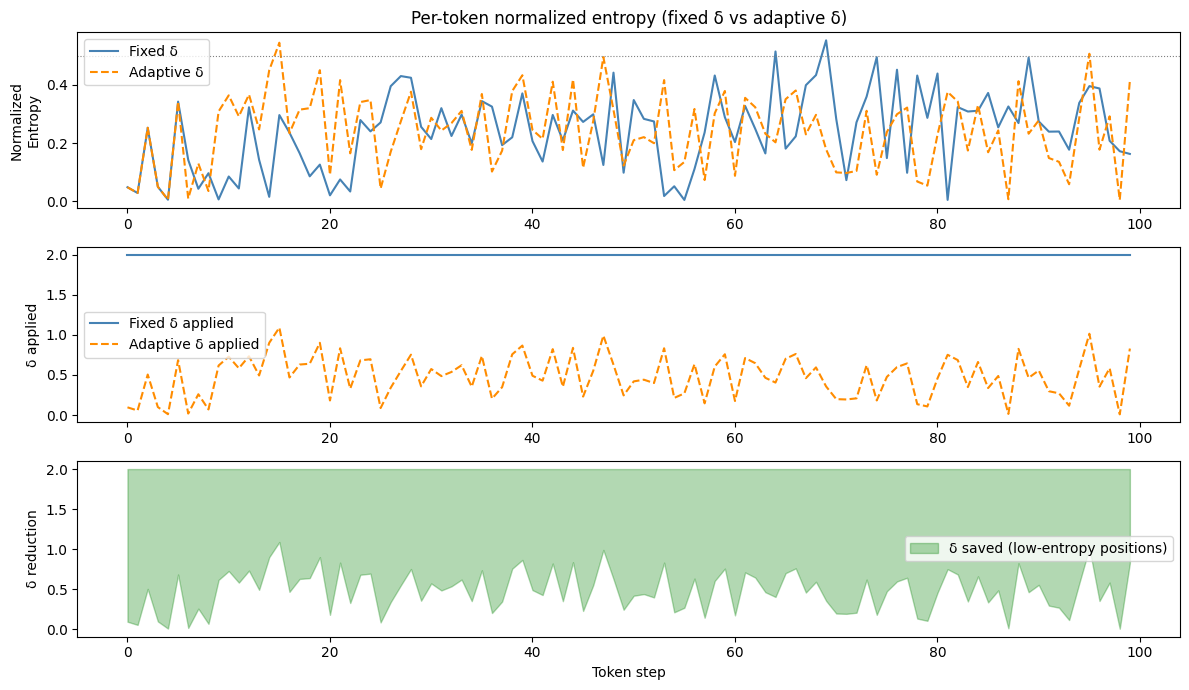

Fixed length: 100 tokens  |  Adaptive: 100 tokens
Avg entropy — Fixed: 0.240  Adaptive: 0.242
Avg δ applied — Fixed: 2.000  Adaptive: 0.485


In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

axes[0].plot(fixed_logger.entropy_log,    label='Fixed δ',    color='steelblue')
axes[0].plot(adaptive_logger.entropy_log, label='Adaptive δ', color='darkorange', linestyle='--')
axes[0].set_ylabel('Normalized\nEntropy')
axes[0].axhline(0.5, color='gray', linewidth=0.8, linestyle=':')
axes[0].legend()
axes[0].set_title('Per-token normalized entropy (fixed δ vs adaptive δ)')

axes[1].plot(fixed_logger.delta_log,    color='steelblue',  label='Fixed δ applied')
axes[1].plot(adaptive_logger.delta_log, color='darkorange', linestyle='--', label='Adaptive δ applied')
axes[1].set_ylabel('δ applied')
axes[1].legend()

adp_steps = range(len(adaptive_logger.delta_log))
axes[2].fill_between(adp_steps, adaptive_logger.delta_log, DELTA,
                     alpha=0.3, color='green', label='δ saved (low-entropy positions)')
axes[2].set_ylabel('δ reduction')
axes[2].set_xlabel('Token step')
axes[2].legend()

plt.tight_layout()
plt.savefig('entropy_vs_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Fixed length: {len(fixed_logger.entropy_log)} tokens  |  Adaptive: {len(adaptive_logger.entropy_log)} tokens')
print(f'Avg entropy — Fixed: {np.mean(fixed_logger.entropy_log):.3f}  Adaptive: {np.mean(adaptive_logger.entropy_log):.3f}')
print(f'Avg δ applied — Fixed: {np.mean(fixed_logger.delta_log):.3f}  Adaptive: {np.mean(adaptive_logger.delta_log):.3f}')


**Note:** Future work should pin the average bias added by the adaptive algorithm to the baseline constant bias from Kirchebauer et al. This implementation fails to add bias that exceeds the original, even in high-entropy settings.

### Forced generation: z-score trajectory

Forced generation runs a loop, checking the running z-score after each token. The plot shows how the z-score grows and where it crosses the detection threshold.

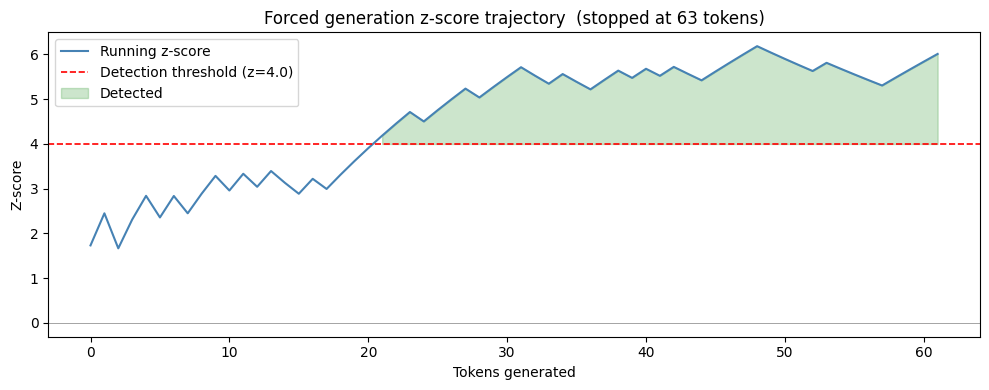

Forced length: 63 tokens  |  final z: 6.01


In [33]:
from generate import generate_until_detected

forced_ids = generate_until_detected(
    model, tokenizer.encode(PROMPT, return_tensors='pt')[0].tolist(),
    watermark_processor, detector,
    max_tokens=800, eos_token_id=tokenizer.eos_token_id, device=DEVICE,
)

z_trajectory = [
    detector.detect(forced_ids[:t+1])['z_score']
    for t in range(1, len(forced_ids))
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_trajectory, color='steelblue', label='Running z-score')
ax.axhline(4.0, color='red', linestyle='--', linewidth=1.2, label='Detection threshold (z=4.0)')
ax.axhline(0,   color='gray', linewidth=0.5)
ax.fill_between(range(len(z_trajectory)), z_trajectory, 4.0,
                where=[z > 4.0 for z in z_trajectory], alpha=0.2, color='green', label='Detected')
ax.set_xlabel('Tokens generated')
ax.set_ylabel('Z-score')
ax.set_title(f'Forced generation z-score trajectory  (stopped at {len(forced_ids)} tokens)')
ax.legend()
plt.tight_layout()
plt.savefig('forced_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Forced length: {len(forced_ids)} tokens  |  final z: {z_trajectory[-1]:.2f}')


### Low-entropy scenario: detection comparison

Run all four conditions on a low-entropy prompt and compare z-scores/detection. Low-entropy prompts (lists, fill-in-the-blank) are where adaptive δ and forced generation are most relevant.

In [34]:
STRUCTURED_PROMPT = (
    "Country: France  Capital: Paris\n"
    "Country: Germany Capital: Berlin\n"
    "Country: Japan   Capital: Tokyo\n"
    "Country: Brazil  Capital:"
)
N_STRUCT = 80

@torch.inference_mode()
def gen(prompt, proc=None, n=N_STRUCT):
    ids = tokenizer.encode(prompt, return_tensors='pt').to(DEVICE)
    out = model.generate(ids, max_new_tokens=n, do_sample=True,
                         logits_processor=[proc] if proc else [])
    return out[0, ids.shape[1]:].tolist()

prompt_ids_struct = tokenizer.encode(STRUCTURED_PROMPT, return_tensors='pt')[0].tolist()

nw_s         = gen(STRUCTURED_PROMPT)
fixed_s      = gen(STRUCTURED_PROMPT, watermark_processor)
adp_s        = gen(STRUCTURED_PROMPT, adaptive_processor)
forced_s     = generate_until_detected(model, prompt_ids_struct, watermark_processor, detector,
                                        max_tokens=400, eos_token_id=tokenizer.eos_token_id, device=DEVICE)
forced_adp_s = generate_until_detected(model, prompt_ids_struct, adaptive_processor, detector,
                                        max_tokens=400, eos_token_id=tokenizer.eos_token_id, device=DEVICE)

rows = [
    ('No watermark',    nw_s),
    ('Fixed δ',         fixed_s),
    ('Adaptive δ',      adp_s),
    ('Forced (fixed)',  forced_s),
    ('Forced (adapt.)', forced_adp_s),
]

print(f'{"Condition":<16}  {"Tokens":>6}  {"Z-score":>8}  {"Detected":>9}  Text preview')
print('-' * 82)
for label, toks in rows:
    r = detector.detect(toks)
    preview = tokenizer.decode(toks[:20], skip_special_tokens=True).replace('\n',' ')
    print(f'{label:<16}  {len(toks):>6}  {r["z_score"]:>8.2f}  {str(r["is_watermarked"]):>9}  {preview}')


Condition         Tokens   Z-score   Detected  Text preview
----------------------------------------------------------------------------------
No watermark           2     -0.58      False   Rio
Fixed δ                4      0.33      False   Rio De Janeiro
Adaptive δ            24      0.12      False   Brasilia Country: Australia  Capital: Sydney Country: US  Capital: Washington, D
Forced (fixed)        38      3.70      False   Brasilia County: Spain County: Austria   Capital: Vienna County
Forced (adapt.)      189      7.41       True   Rio de Janeiro Country: Germany  Capital: Frankfurt Although you can enter Paris from Marseille


**Note:** In this case, the forced generation with adaptive bias is the only condition to render an observable watermark.

### Bulk evaluation results

In [ ]:
# !python generate.py --num_samples 500 --output_file data/generations.jsonl

In [ ]:
# !python evaluate.py --input_file data/generations.jsonl


                             ── Low entropy ──                          ── High entropy ──            
                     TPR  Z-mean    Len     PPL       TPR  Z-mean    Len     PPL
───────────────────────────────────────────────────────────────────────────────────────────────
Fixed δ            0.968    9.99  178.4   12.13     0.984   10.30  187.7   12.19
Adaptive δ         0.196    2.75  178.9    9.21     0.196    2.94  187.9    9.12
Forced (fixed)     1.000    4.26   33.3   38.52     1.000    4.25   34.3   40.47
Forced (adapt.)    0.984    7.94  325.5   24.87     0.976    8.06  358.2   23.47


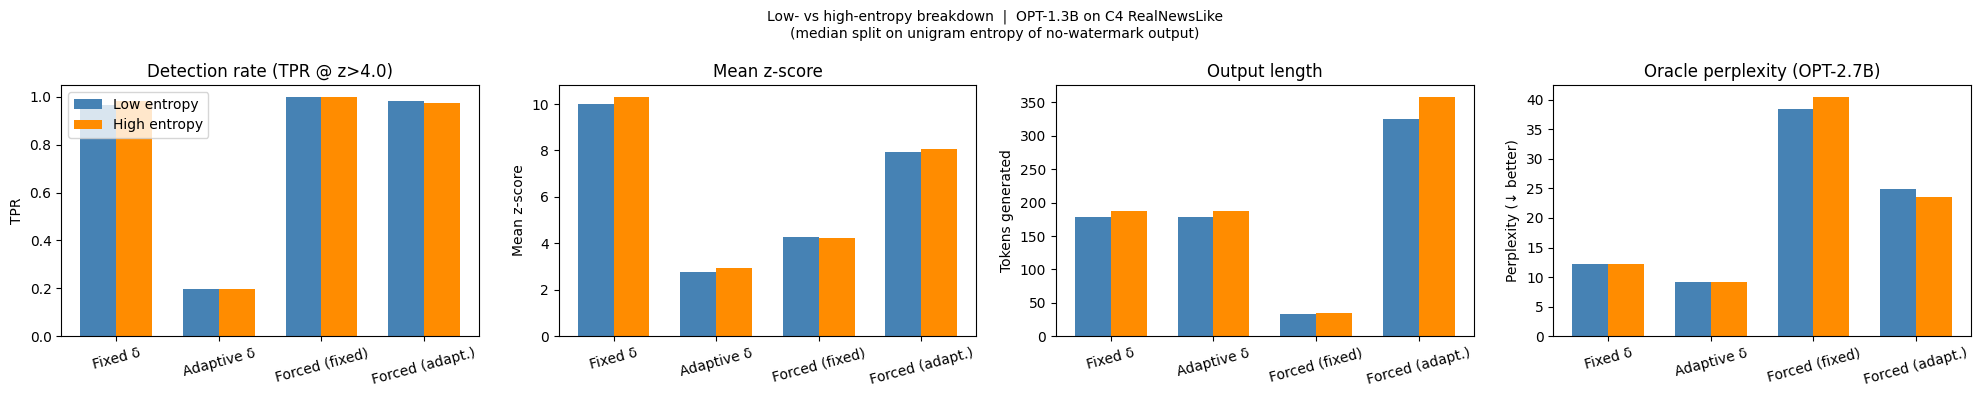


── Conclusions ──

  Fixed δ:
    TPR   low=0.968  high=0.984  drop=-0.016
    Z     low=9.99  high=10.30
    PPL   low=12.13 (+3.14 vs no-wm)  high=12.19 (+3.20 vs no-wm)
    Len   low=178.4  high=187.7 tokens

  Adaptive δ:
    TPR   low=0.196  high=0.196  drop=+0.000
    Z     low=2.75  high=2.94
    PPL   low=9.21 (+0.22 vs no-wm)  high=9.12 (+0.13 vs no-wm)
    Len   low=178.9  high=187.9 tokens

  Forced (fixed):
    TPR   low=1.000  high=1.000  drop=+0.000
    Z     low=4.26  high=4.25
    PPL   low=38.52 (+29.53 vs no-wm)  high=40.47 (+31.48 vs no-wm)
    Len   low=33.3  high=34.3 tokens

  Forced (adapt.):
    TPR   low=0.984  high=0.976  drop=+0.008
    Z     low=7.94  high=8.06
    PPL   low=24.87 (+15.88 vs no-wm)  high=23.47 (+14.48 vs no-wm)
    Len   low=325.5  high=358.2 tokens


In [35]:
# Low-entropy performance breakdown
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from watermark import WatermarkDetector

records   = [json.loads(l) for l in Path('data/generations.jsonl').read_text().strip().split('\n')]
eval_path = Path('data/generations.eval.json')
ev        = json.loads(eval_path.read_text()) if eval_path.exists() else {}

detector = WatermarkDetector(vocab_size=vocab_size, gamma=GAMMA, hash_key=HASH_KEY, z_threshold=4.0)

def seq_entropy(toks):
    counts = np.bincount(toks)
    p = counts[counts > 0] / len(toks)
    return float(-np.sum(p * np.log(p)))

entropies = np.array([seq_entropy(r['no_watermark_tokens']) for r in records])
median_h  = np.median(entropies)
low_mask  = entropies < median_h
high_mask = ~low_mask

def score(recs, mask, tok_key, ppl_list=None):
    idx  = [i for i, m in enumerate(mask) if m and tok_key in recs[i]]
    zs   = [detector.detect(recs[i][tok_key])['z_score'] for i in idx]
    lens = [len(recs[i][tok_key]) for i in idx]
    ppls = [ppl_list[i] for i in idx] if ppl_list else None
    return dict(tpr=np.mean([z > 4.0 for z in zs]),
                z_mean=np.mean(zs),
                len_mean=np.mean(lens),
                ppl_mean=np.nanmean(ppls) if ppls else None)

conditions = {
    'Fixed δ':         ('watermarked_tokens',  ev.get('w_ppls')),
    'Adaptive δ':      ('adaptive_tokens',     ev.get('adp_ppls')),
    'Forced (fixed)':  ('forced_tokens',       ev.get('forced_ppls')),
    'Forced (adapt.)': ('forced_adp_tokens',   ev.get('forced_adp_ppls')),
}

stats = {}
for split, mask in [('Low', low_mask), ('High', high_mask)]:
    stats[split] = {}
    for cond, (tok_key, ppl_list) in conditions.items():
        if tok_key in records[0]:
            stats[split][cond] = score(records, mask, tok_key, ppl_list)

conds   = list(stats['Low'].keys())
has_ppl = any(stats['Low'][c]['ppl_mean'] is not None for c in conds)

# Print table
ppl_h = f"{'PPL':>7}" if has_ppl else ''
w_col = 42 if has_ppl else 28
print(f"\n{'':16} {'── Low entropy ──':^{w_col}} {'── High entropy ──':^{w_col}}")
print(f"{'':16} {'TPR':>7} {'Z-mean':>7} {'Len':>6}{' '+ppl_h if has_ppl else ''}   {'TPR':>7} {'Z-mean':>7} {'Len':>6}{' '+ppl_h if has_ppl else ''}")
print('─' * (95 if has_ppl else 76))
for c in conds:
    lo, hi = stats['Low'][c], stats['High'][c]
    ppl_lo = f"  {lo['ppl_mean']:>6.2f}" if has_ppl and lo['ppl_mean'] else ''
    ppl_hi = f"  {hi['ppl_mean']:>6.2f}" if has_ppl and hi['ppl_mean'] else ''
    print(f"{c:16} {lo['tpr']:>7.3f} {lo['z_mean']:>7.2f} {lo['len_mean']:>6.1f}{ppl_lo}"
          f"   {hi['tpr']:>7.3f} {hi['z_mean']:>7.2f} {hi['len_mean']:>6.1f}{ppl_hi}")

# Plots
n_plots = 4 if has_ppl else 3
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
x, w = np.arange(len(conds)), 0.35

metrics = [
    ('tpr',      'TPR',                  'Detection rate (TPR @ z>4.0)'),
    ('z_mean',   'Mean z-score',         'Mean z-score'),
    ('len_mean', 'Tokens generated',     'Output length'),
]
if has_ppl:
    metrics.append(('ppl_mean', 'Perplexity (↓ better)', 'Oracle perplexity (OPT-2.7B)'))

for ax, (metric, ylabel, title) in zip(axes, metrics):
    lo_vals = [stats['Low'][c][metric]  or 0 for c in conds]
    hi_vals = [stats['High'][c][metric] or 0 for c in conds]
    ax.bar(x - w/2, lo_vals, w, label='Low entropy',  color='steelblue')
    ax.bar(x + w/2, hi_vals, w, label='High entropy', color='darkorange')
    ax.set_xticks(x); ax.set_xticklabels(conds, rotation=15)
    ax.set_ylabel(ylabel); ax.set_title(title)
    if metric == 'tpr': ax.set_ylim(0, 1.05)
axes[0].legend()

plt.suptitle('Low- vs high-entropy breakdown  |  OPT-1.3B on C4 RealNewsLike\n'
             '(median split on unigram entropy of no-watermark output)', fontsize=10)
plt.tight_layout()
plt.savefig('entropy_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusions
nw_ppl = ev.get('nw_ppl_mean')
print('\n── Conclusions ──')
for c in conds:
    lo, hi = stats['Low'][c], stats['High'][c]
    print(f"\n  {c}:")
    print(f"    TPR   low={lo['tpr']:.3f}  high={hi['tpr']:.3f}  drop={lo['tpr']-hi['tpr']:+.3f}")
    print(f"    Z     low={lo['z_mean']:.2f}  high={hi['z_mean']:.2f}")
    if lo['ppl_mean']:
        ppl_vs_nw_lo = lo['ppl_mean'] - nw_ppl if nw_ppl else 0
        ppl_vs_nw_hi = hi['ppl_mean'] - nw_ppl if nw_ppl else 0
        print(f"    PPL   low={lo['ppl_mean']:.2f} ({ppl_vs_nw_lo:+.2f} vs no-wm)  "
              f"high={hi['ppl_mean']:.2f} ({ppl_vs_nw_hi:+.2f} vs no-wm)")
    print(f"    Len   low={lo['len_mean']:.1f}  high={hi['len_mean']:.1f} tokens")


### Observation

It is clear the C4 RealNewsLike dataset does not expose the low-entropy failure mode sufficiently.

Below is a comparison to manually curated low-entropy prompts.

Running 50 low-entropy prompts …
  10/50
  20/50
  30/50
  40/50
  50/50


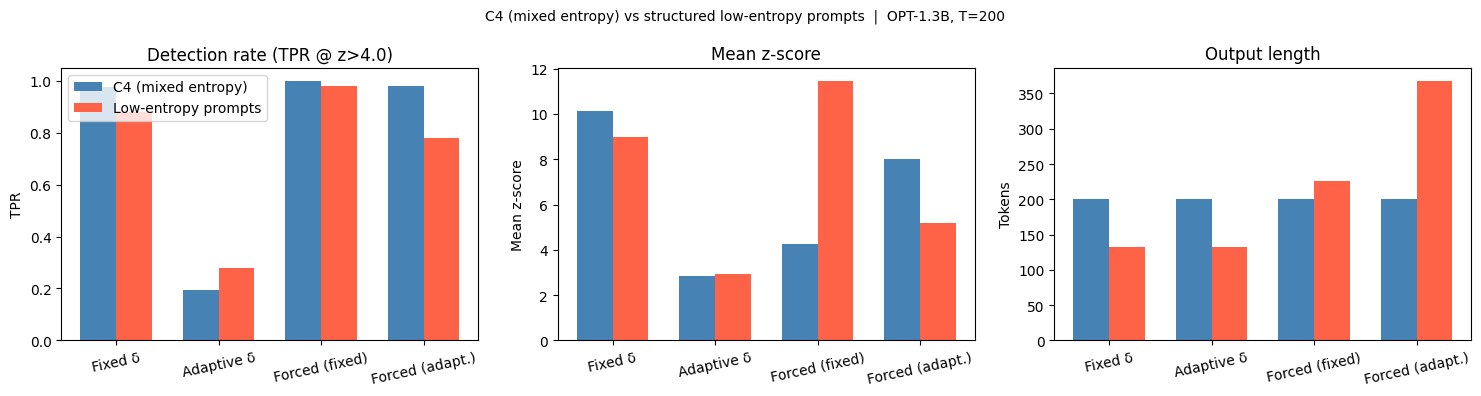


── Results ──
                   C4 TPR   LE TPR     C4 Z     LE Z   LE Len
────────────────────────────────────────────────────────────
Fixed δ             0.976    0.880    10.15     9.00    132.1
Adaptive δ          0.196    0.280     2.84     2.92    132.2
Forced (fixed)      1.000    0.980     4.26    11.46    225.8
Forced (adapt.)     0.980    0.780     8.00     5.18    368.0


In [41]:
# Low-entropy prompt evaluation
import subprocess, json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from generate import generate_until_detected

if not Path('data/low_entropy_prompts.jsonl').exists():
    subprocess.run(['python', 'make_low_entropy_prompts.py'], check=True)

le_prompts = [json.loads(l) for l in Path('data/low_entropy_prompts.jsonl').read_text().strip().split('\n')]
N_LE = 50

# Load per-record PPL from eval JSON
ev = json.loads(Path('data/generations.eval.json').read_text()) if Path('data/generations.eval.json').exists() else {}

conditions = {
    'Fixed δ':         ('generate_one', watermark_processor),
    'Adaptive δ':      ('generate_one', adaptive_processor),
    'Forced (fixed)':  ('forced',       watermark_processor),
    'Forced (adapt.)': ('forced',       adaptive_processor),
}

results_le = {c: {'zscores': [], 'lengths': []} for c in conditions}

@torch.inference_mode()
def gen_le(prompt_ids, proc=None, n=200):
    ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    out = model.generate(ids, max_new_tokens=n, do_sample=True,
                         logits_processor=[proc] if proc else [])
    return out[0, ids.shape[1]:].tolist()

print(f"Running {N_LE} low-entropy prompts …")
for i, rec in enumerate(le_prompts[:N_LE]):
    prompt_ids = tokenizer.encode(rec['prompt'])
    for cname, (mode, proc) in conditions.items():
        if mode == 'generate_one':
            toks = gen_le(prompt_ids, proc)
        else:
            toks = generate_until_detected(model, prompt_ids, proc, detector,
                                           max_tokens=400, eos_token_id=tokenizer.eos_token_id,
                                           device=DEVICE)
        z = detector.detect(toks)['z_score']
        results_le[cname]['zscores'].append(z)
        results_le[cname]['lengths'].append(len(toks))
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_LE}", flush=True)

# Compare to C4 results
c4_z   = [ev.get('w_z_mean'), ev.get('adp_z_mean'), ev.get('forced_z_mean'), ev.get('forced_adp_z_mean')]
c4_tpr = [ev.get('tpr'),      ev.get('adp_tpr'),    ev.get('forced_tpr'),    ev.get('forced_adp_tpr')]
conds  = list(conditions.keys())
le_z   = [np.mean(results_le[c]['zscores'])              for c in conds]
le_tpr = [np.mean([z > 4.0 for z in results_le[c]['zscores']]) for c in conds]
le_len = [np.mean(results_le[c]['lengths'])              for c in conds]

x, w = np.arange(len(conds)), 0.35
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (c4_vals, le_vals, ylabel, title) in zip(axes, [
    (c4_tpr, le_tpr, 'TPR',           'Detection rate (TPR @ z>4.0)'),
    (c4_z,   le_z,   'Mean z-score',  'Mean z-score'),
    ([200]*4, le_len, 'Tokens',        'Output length'),
]):
    ax.bar(x - w/2, [v or 0 for v in c4_vals], w, label='C4 (mixed entropy)', color='steelblue')
    ax.bar(x + w/2, le_vals,                    w, label='Low-entropy prompts', color='tomato')
    ax.set_xticks(x); ax.set_xticklabels(conds, rotation=12)
    ax.set_ylabel(ylabel); ax.set_title(title)
    if ylabel == 'TPR': ax.set_ylim(0, 1.05)
axes[0].legend()

plt.suptitle('C4 (mixed entropy) vs structured low-entropy prompts  |  OPT-1.3B, T=200', fontsize=10)
plt.tight_layout()
plt.savefig('low_entropy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Results ──')
print(f"{'':16} {'C4 TPR':>8} {'LE TPR':>8} {'C4 Z':>8} {'LE Z':>8} {'LE Len':>8}")
print('─' * 60)
for c, cz, lz, ct, lt, ll in zip(conds, c4_z, le_z, c4_tpr, le_tpr, le_len):
    print(f"{c:16} {ct or 0:>8.3f} {lt:>8.3f} {cz or 0:>8.2f} {lz:>8.2f} {ll:>8.1f}")
